In [28]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt # THIS ISN't FUNCTIONAL, IT's JUST TEMPORARY
import time
from waveNetArchitecture import Value, Linear, BatchNorm1D, Tanh, Embedding, FlattenConsecutive, Sequential, cross_entropy
with open('shakespear.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [64]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

blockSize = 8 # Increase the amount of context
inputs, outputs = [],[]
print(chars)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [30]:
data = Value(encode(text))
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]
print(data.data[:20])

[18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56]


In [31]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP

# each FlattenConsecutive(2) concatenates 2 neighbours, so the next Linear sees 2x the features
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# last layer: make less confident
model.layers[-1].weight.data *= 0.1
# all other layers: apply gain
for layer in model.layers[:-1]:
    if isinstance(layer, Linear):
        layer.weight.data *= 1.0 #5/3

parameters = model.parameters()
print(sum(p.data.size for p in parameters)) # number of parameters in total

49815


In [63]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for layer in model.layers:
    if isinstance(layer, BatchNorm1D):
        layer.training = True # train mode: use batch stats and update the running buffers

# build sliding-window dataset: each input is `blockSize` consecutive tokens,
# target is the next token
tokens = data.data
X, Y = [], []
for j in range(len(tokens) - blockSize):
    X.append(tokens[j : j + blockSize]) # (blockSize,) context indices
    Y.append(tokens[j + blockSize])     # () next-token target
trainInArr = np.array(X)   # (N, blockSize)
trainOutArr = np.array(Y)  # (N,)

for i in range(max_steps):

    # minibatch construct
    ix = np.random.randint(0, trainInArr.shape[0], (batch_size,))
    Xb, Yb = trainInArr[ix], trainOutArr[ix]  # (batch_size, blockSize), (batch_size,)

    # forward pass
    logits = model(Xb)
    loss = cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = np.zeros_like(p.data, dtype=float)
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {float(loss.data):.4f}')
    lossi.append(np.log10(float(loss.data)))
    ud.append([np.log10(np.std(lr * p.grad) / np.std(p.data)) for p in parameters])

    if i >= 1000:
        # break # If you want to.
        pass

      0/ 200000: 1.5635
  10000/ 200000: 1.6112
  20000/ 200000: 1.4913
  30000/ 200000: 2.1116
  40000/ 200000: 1.7111
  50000/ 200000: 1.7751
  60000/ 200000: 1.6159
  70000/ 200000: 1.5310
  80000/ 200000: 1.5530


KeyboardInterrupt: 

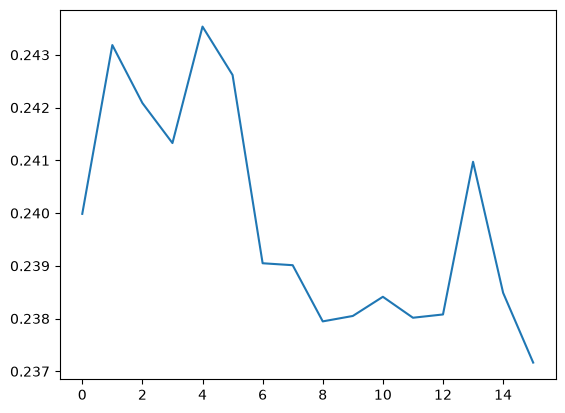

In [ ]:
SMUSH = 1000 # resolution of graph. <50 really has too much noise, 1000 is reccomended. Needed bc 32 as a batch size has too much variation.
betterLoss = []
cur = 0
for i in range(len(lossi)):
    cur += lossi[i]
    if i % SMUSH == 0 and i>0:
        betterLoss.append(cur/SMUSH)
        cur = 0
betterLoss.append(cur/(len(lossi)%SMUSH))

plt.plot(betterLoss)

In [76]:
# put batchnorm layers into eval mode so they use the running stats instead of
# per-batch stats (a batch of size 1 has zero variance, which would blow up otherwise)
for layer in model.layers:
    if isinstance(layer, BatchNorm1D):
        layer.training = False

# sample from the model
rng = np.random

for _ in range(20):

    out = []
    context = [26] * blockSize # initialize with the '.' padding token
    while True:
        # forward pass the neural net: feed the (1, blockSize) context of indices
        x = np.array([context]) # (1, blockSize); the Embedding layer looks these up
        logits = model(x)
        e = np.exp(logits.data)
        probs = e / e.sum(axis=1, keepdims=True)
        # sample from the distribution
        ix = rng.choice(vocab_size, p=probs[0])
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 26:
            break

    print(''.join(itos[i] for i in out[:-1])) # decode and print the generated word, dropping the trailing '.'

:
Why, but him knuly fue wold'st, not retures, Angely brod. Fiervey kirdice taids and not by, if well-place on't, an by foll him and reasons;
Lasting upon,' a bears, is ip belims
And the nay them preter; retuer Bill bucusing thank but
As irns wish of Greir.

HORK CLI
IO:
Rill deed, tell sum,
Sair wooth.

KI
VOLFFOMEO
:

A:
Which  and you us not Muitorg to brage noble bube 'trantry surl men us of knowperefore be not be we'll we find!
Why bittle fly for and atter's think.

SICI
A:
Gientlemble mut hate,
Will,
And be the bear dimst me at auth
Taknored to well of his ill litter with Gage to scortcay of at a father mercy,
My name your soul:
But entrubble.
And I'll so exjouding son. While, to wish.
Sirwer it oporiccout strike,
The agaye
Lome on God we his gries nobless a king a hatht, or tuse
And sadd
Be purn ungers, to vait by thear what seems,

:
Go say.

DUKE VI
ES:
Mould as as wuth will briam,
Give your botest of our be a forth fur your back
Or my go could us the usater un your be had the

In [ ]:
#Asking it what's for dinner.

for layer in model.layers:
    if isinstance(layer, BatchNorm1D):
        layer.training = False

# sample from the model
rng = np.random

for _ in range(20):

    out = []
    context = [8, 42, 47, 52, 52, 43, 56, 12] # Asking it what's for dinner
    # We need . d i n n n e r ?
    while True:
        # forward pass the neural net: feed the (1, blockSize) context of indices
        x = np.array([context]) # (1, blockSize); the Embedding layer looks these up
        logits = model(x)
        e = np.exp(logits.data)
        probs = e / e.sum(axis=1, keepdims=True)
        # sample from the distribution
        ix = rng.choice(vocab_size, p=probs[0])
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 26:
            break

    print(''.join(itos[i] for i in out[:-1])) # decode and print the generated word, dropping the trailing '.'



BRUTUS:
Fe'er in be after in,

First the turpt the he gray wilt be be not's in is my name prove as stow city so. I husbe, but yet me hath me, if all him, tua not is consouded fear Lords,
Fis not which blood
Than we hand
'Tis and death nook
Of Horst;
I commikh, ut be suwerful a both,
Thou lay but druuding you
Wister's of gnom where net he again to off intrucodself my be husbance, they chat is my father's disced fur decition;
And be not
Ofhing day
Letch, I disperice,
The is spe wize sak upon;
How surkely slave thanks;
Which nurnt before a charge all speak somprester, of us, it is before's say, or death, say of offe jastry, who be a all belied. Ex my lord wand his diso 'Ck
Fetchas my scorce beaashen fainty's Ifford thee tall be hading by outs. Buta:
If it:
That country Peremploshall have beening Grether:
So heart be gone a dearfues, Vervine of you sale.

ROMEO:
Fort up gench be Hese'st will be by you so in upon! Caus 'twart o'ert,
Gor farth, batiies a poor of the kimfdess, sir, I nught 